In [30]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.model_selection import ParameterGrid
import pacmap
import time

In [31]:
# Load the MNIST dataset from sklearn.
# X_mnist --> flattened 28×28 grayscale digit images (values 0–255)
# y_mnist --> digit labels 0–9.
X_mnist, y_mnist = fetch_openml(name='mnist_784', version=1, return_X_y=True, as_frame=False)

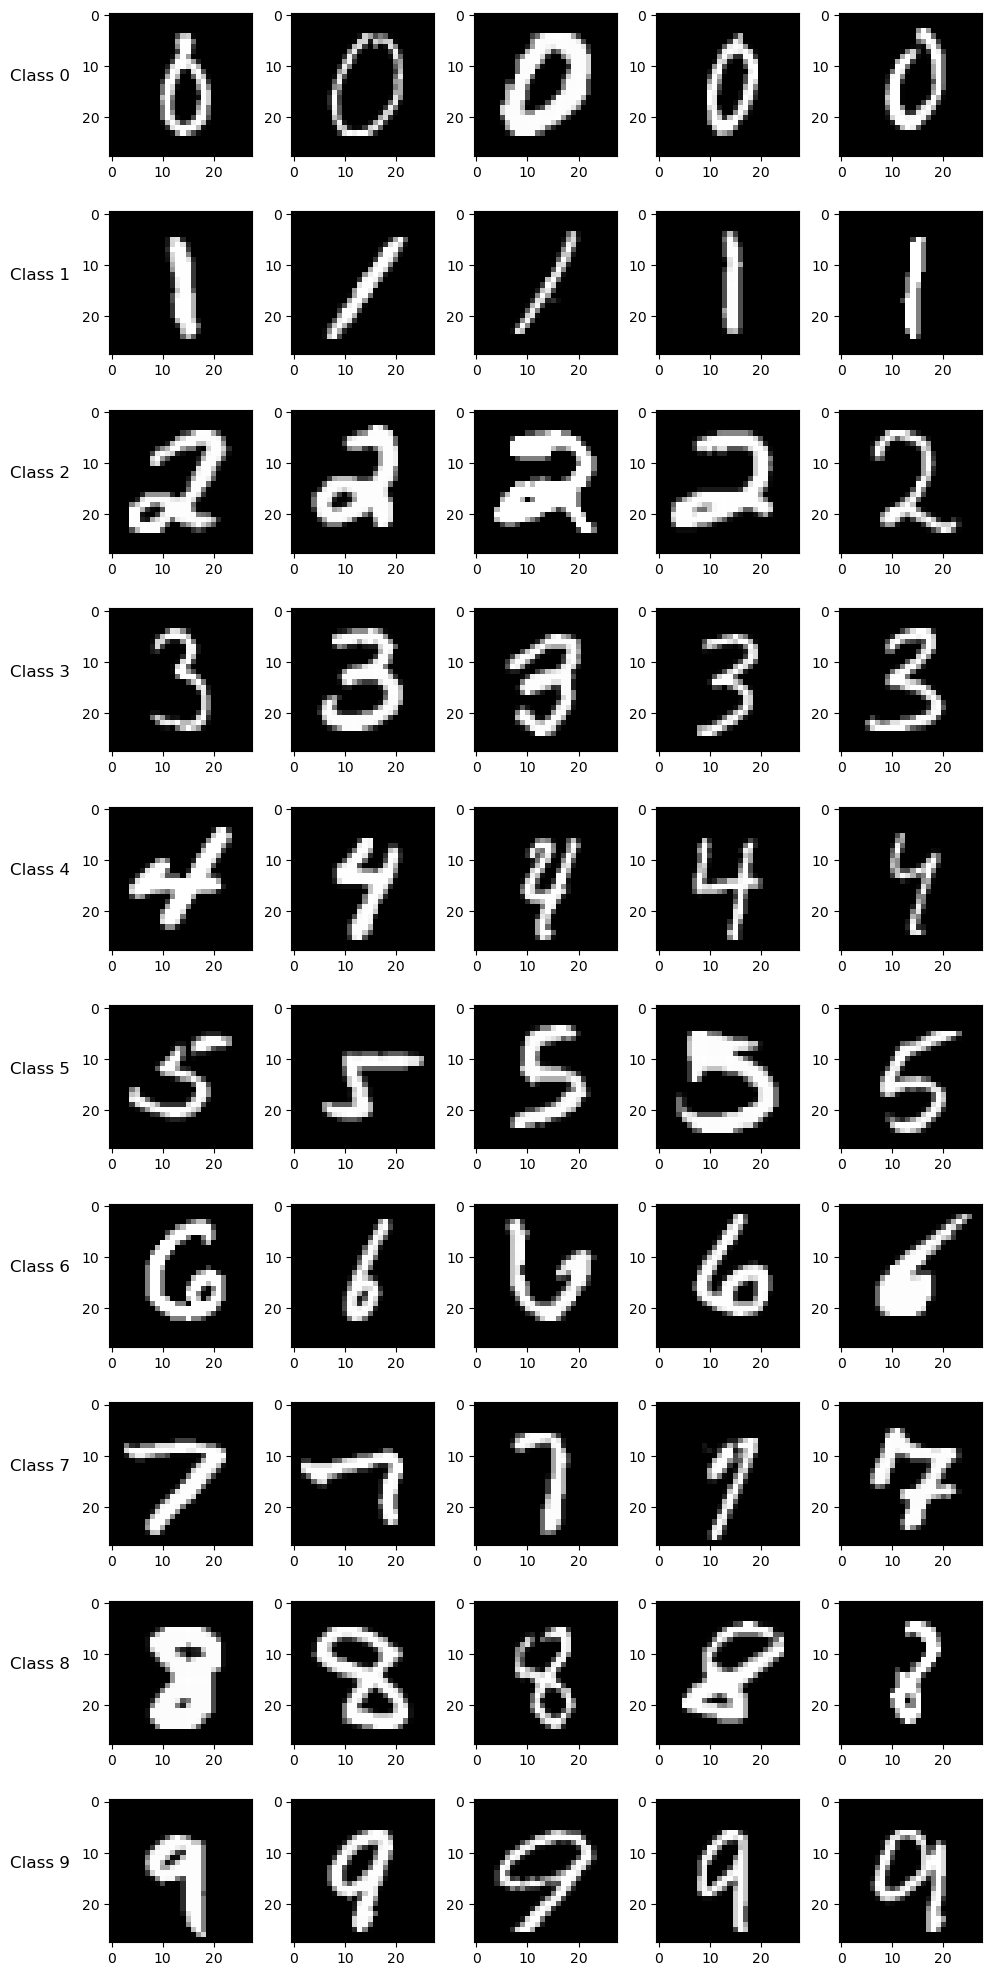

In [3]:
# Reshape flattened vectors (784 dims) back into 28×28 images for visualization.
# This is only for plotting
X_images = X_mnist.reshape(-1, 28, 28)

num_imgs = 5

fig, axes = plt.subplots(10, 5, figsize=(10, 20))

for i in range(10):

    # Select all indices belonging to class i, randomly sample 5 images from that class
    idx = np.where(y_mnist.astype(int) == i)[0]
    chosen = np.random.choice(idx, num_imgs, replace=False)

    for col, img_idx in enumerate(chosen):
        ax = axes[i, col]
        ax.imshow(X_images[img_idx], cmap='gray')
        if col == 0:
            ax.set_ylabel(f"Class {i}", fontsize=12, rotation=0, labelpad=30)

plt.tight_layout()
plt.show()

### Observations from Sample MNIST Images

The sample grid shows that some digits (e.g., **0**, **1**) have very consistent shapes, while others (e.g., **4**, **7**, **8**, **9**) show large intra-class variability. Such variability makes clustering harder, especially for **K-means**, which assumes spherical clusters, and **GMM**, which assumes Gaussian structure in feature space. Digits with overlapping shapes (e.g., **3 vs 5**, **4 vs 9**) are therefore expected to confuse the clustering algorithms.


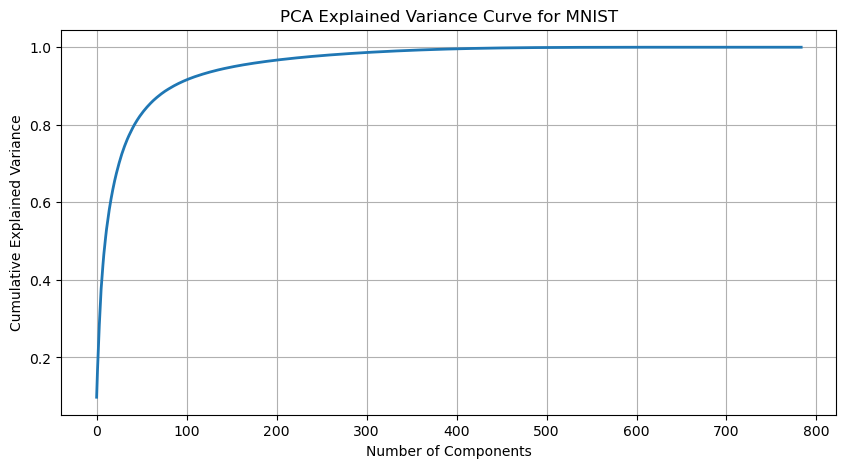

90% variance explained by ~87 components
95% variance explained by ~154 components
98% variance explained by ~260 components
99% variance explained by ~331 components


In [6]:
pca_full = PCA(n_components=None, random_state=5)
pca_full.fit(X_mnist)

# Explained variance ratio
var_ratio = pca_full.explained_variance_ratio_

# Cumulative variance
cum_var = np.cumsum(var_ratio)

# Plot cumulative explained variance
plt.figure(figsize=(10, 5))
plt.plot(cum_var, linewidth=2)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Curve for MNIST")
plt.grid(True)
plt.show()

# Print useful thresholds
for threshold in [0.90, 0.95, 0.98, 0.99]:
    n_components = np.argmax(cum_var >= threshold) + 1
    print(f"{threshold*100:.0f}% variance explained by ~{n_components} components")

### PCA for Dimensionality Reduction
Clustering MNIST in the full 784-dimensional space is inefficient and noisy due to the curse of dimensionality.  
PCA compresses the data while keeping most structure. From the explained-variance curve:  
- 90% → ~87 comps  
- 95% → ~154 comps  
- 98% → ~260 comps  
- 99% → ~331 comps  

I initially experimented with 100–250 PCA components since they retain most variance while reducing computation.

### K-means with High PCA Dimensions
I first tested K-means using high PCA dimensions (100–250) with a broad hyperparameter grid.  
The results were poor: silhouette scores decreased and ARI barely changed across settings.  
This suggests that many high-variance PCA components are redundant for clustering and may introduce noise.
Because the outputs were very large and uninformative, they were removed and replaced by a cleaner second experiment.

In [7]:
'''
# originally tested k means with:
pca_high_dims = [100,150,200,250]
kmeans_first_grid = {
    'n_clusters': [8,10,12,14],                   
    'init': ['k-means++', 'random'],
    'n_init': [10, 20],
    'max_iter': [300],
    'algorithm': ['lloyd']
}
# graphs showed these many dimensions are redundant so experimented with lower dimensions further down
'''

### K-means with Low PCA Dimensions
Based on the earlier results, I re-ran K-means using lower PCA dimensions (10–100).  
In the initial high-dimensional run, I tested several cluster counts (8, 10, 12) and found that 8 clusters achieved the highest scores.  
However, since MNIST naturally contains 10 digit classes, I fixed `n_clusters = 10` for the refined experiment and tuned the remaining hyperparameters.

This setup produced clearer patterns and more meaningful clustering scores, so these results are used for comparison.

### Selecting the Best K-Means Model Per PCA Dimension
For each PCA dimensionality, all hyperparameter combinations are evaluated, and the configuration with the highest silhouette score is selected as the “best model” for that dimension.  
These best-per-dimension results are then compared in a summary plot, showing how silhouette, ARI, and NMI vary with the number of PCA components.

In [10]:
# Load MNIST
X = X_mnist / 255.0
y = y_mnist.astype(int)

Starting PCA + K-Means experiments...


================ PCA = 10 components ================

Testing: {'algorithm': 'lloyd', 'init': 'k-means++', 'max_iter': 300, 'n_clusters': 10, 'n_init': 10}
 --> Silhouette=0.1629 | ARI=0.3370 | NMI=0.4659 | time=1.02s
Testing: {'algorithm': 'lloyd', 'init': 'k-means++', 'max_iter': 300, 'n_clusters': 10, 'n_init': 20}
 --> Silhouette=0.1653 | ARI=0.3370 | NMI=0.4659 | time=1.75s
Testing: {'algorithm': 'lloyd', 'init': 'random', 'max_iter': 300, 'n_clusters': 10, 'n_init': 10}
 --> Silhouette=0.1714 | ARI=0.3376 | NMI=0.4661 | time=0.67s
Testing: {'algorithm': 'lloyd', 'init': 'random', 'max_iter': 300, 'n_clusters': 10, 'n_init': 20}
 --> Silhouette=0.1662 | ARI=0.3372 | NMI=0.4663 | time=1.25s
Testing: {'algorithm': 'elkan', 'init': 'k-means++', 'max_iter': 300, 'n_clusters': 10, 'n_init': 10}
 --> Silhouette=0.1687 | ARI=0.3370 | NMI=0.4659 | time=1.10s
Testing: {'algorithm': 'elkan', 'init': 'k-means++', 'max_iter': 300, 'n_clusters': 10, 'n_

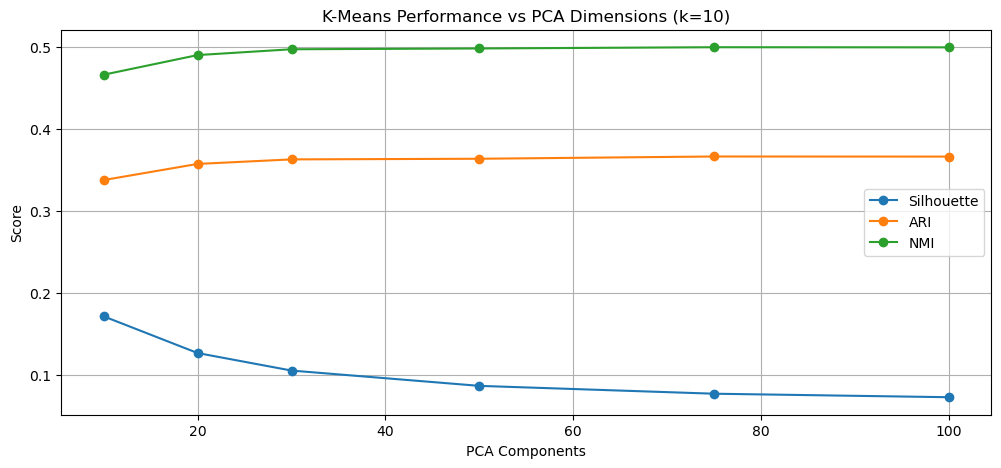

In [6]:
# PCA dimensions to test (new smaller range)
pca_dims = [10, 20, 30, 50, 75, 100]


# K-Means hyperparameter grid (fixed k=10)
kmeans_grid = {
    'n_clusters': [10],                     # fixed to true numebr of classes
    'init': ['k-means++', 'random'],
    'n_init': [10, 20],
    'max_iter': [300],
    'algorithm': ['lloyd', 'elkan']
}

results = []


for dim in pca_dims:
    print(f"\n================ PCA = {dim} components ================\n")

    # Apply PCA
    pca = PCA(n_components=dim, random_state=5)
    X_pca = pca.fit_transform(X)

    best_sil = -1
    best_result = None

    # Try each KMeans configuration
    for params in ParameterGrid(kmeans_grid):
        print(f"Testing: {params}")
        start = time.time()

        km = KMeans(**params, random_state=42)
        labels = km.fit_predict(X_pca)

        # Metrics
        inertia = km.inertia_
        sil = silhouette_score(X_pca, labels, sample_size=5000)
        ari = adjusted_rand_score(y, labels)
        nmi = normalized_mutual_info_score(y, labels)
        elapsed = time.time() - start

        print(f" --> Silhouette={sil:.4f} | ARI={ari:.4f} | NMI={nmi:.4f} | time={elapsed:.2f}s")

        # Track best for this PCA size
        if sil > best_sil:
            best_sil = sil
            best_result = {
                "pca_dim": dim,
                "params": params,
                "silhouette": sil,
                "ari": ari,
                "nmi": nmi,
                "inertia": inertia,
                "time": elapsed
            }

    results.append(best_result)
    print("\nBest for PCA =", dim)
    print(best_result)

# Plot metrics vs PCA dimension
dims = [r['pca_dim'] for r in results]
sil_vals = [r['silhouette'] for r in results]
ari_vals = [r['ari'] for r in results]
nmi_vals = [r['nmi'] for r in results]

plt.figure(figsize=(12,5))
plt.plot(dims, sil_vals, marker='o', label='Silhouette')
plt.plot(dims, ari_vals, marker='o', label='ARI')
plt.plot(dims, nmi_vals, marker='o', label='NMI')
plt.xlabel("PCA Components")
plt.ylabel("Score")
plt.title("K-Means Performance vs PCA Dimensions (k=10)")
plt.grid(True)
plt.legend()
plt.show()

In [18]:
# from the previous results, 20 dimensions gives the best trade-off between the scores
pca = PCA(n_components=20, random_state=5)
X_kmeans_pca = pca.fit_transform(X)

# Best K-Means model
best_params = {
    'algorithm': 'lloyd',
    'init': 'k-means++',
    'max_iter': 300,
    'n_clusters': 10,
    'n_init': 10
}

kmeans = KMeans(**best_params, random_state=42)
kmeans_labels = kmeans.fit_predict(X_kmeans_pca)

X_images = X.reshape(-1, 28, 28)

### Why Use 20 PCA Components?
The PCA sweep showed that 20 components gave the highest silhouette score and stable ARI/NMI values.  
Higher dimensions added noise without improving clustering, so 20 offered the best trade-off.

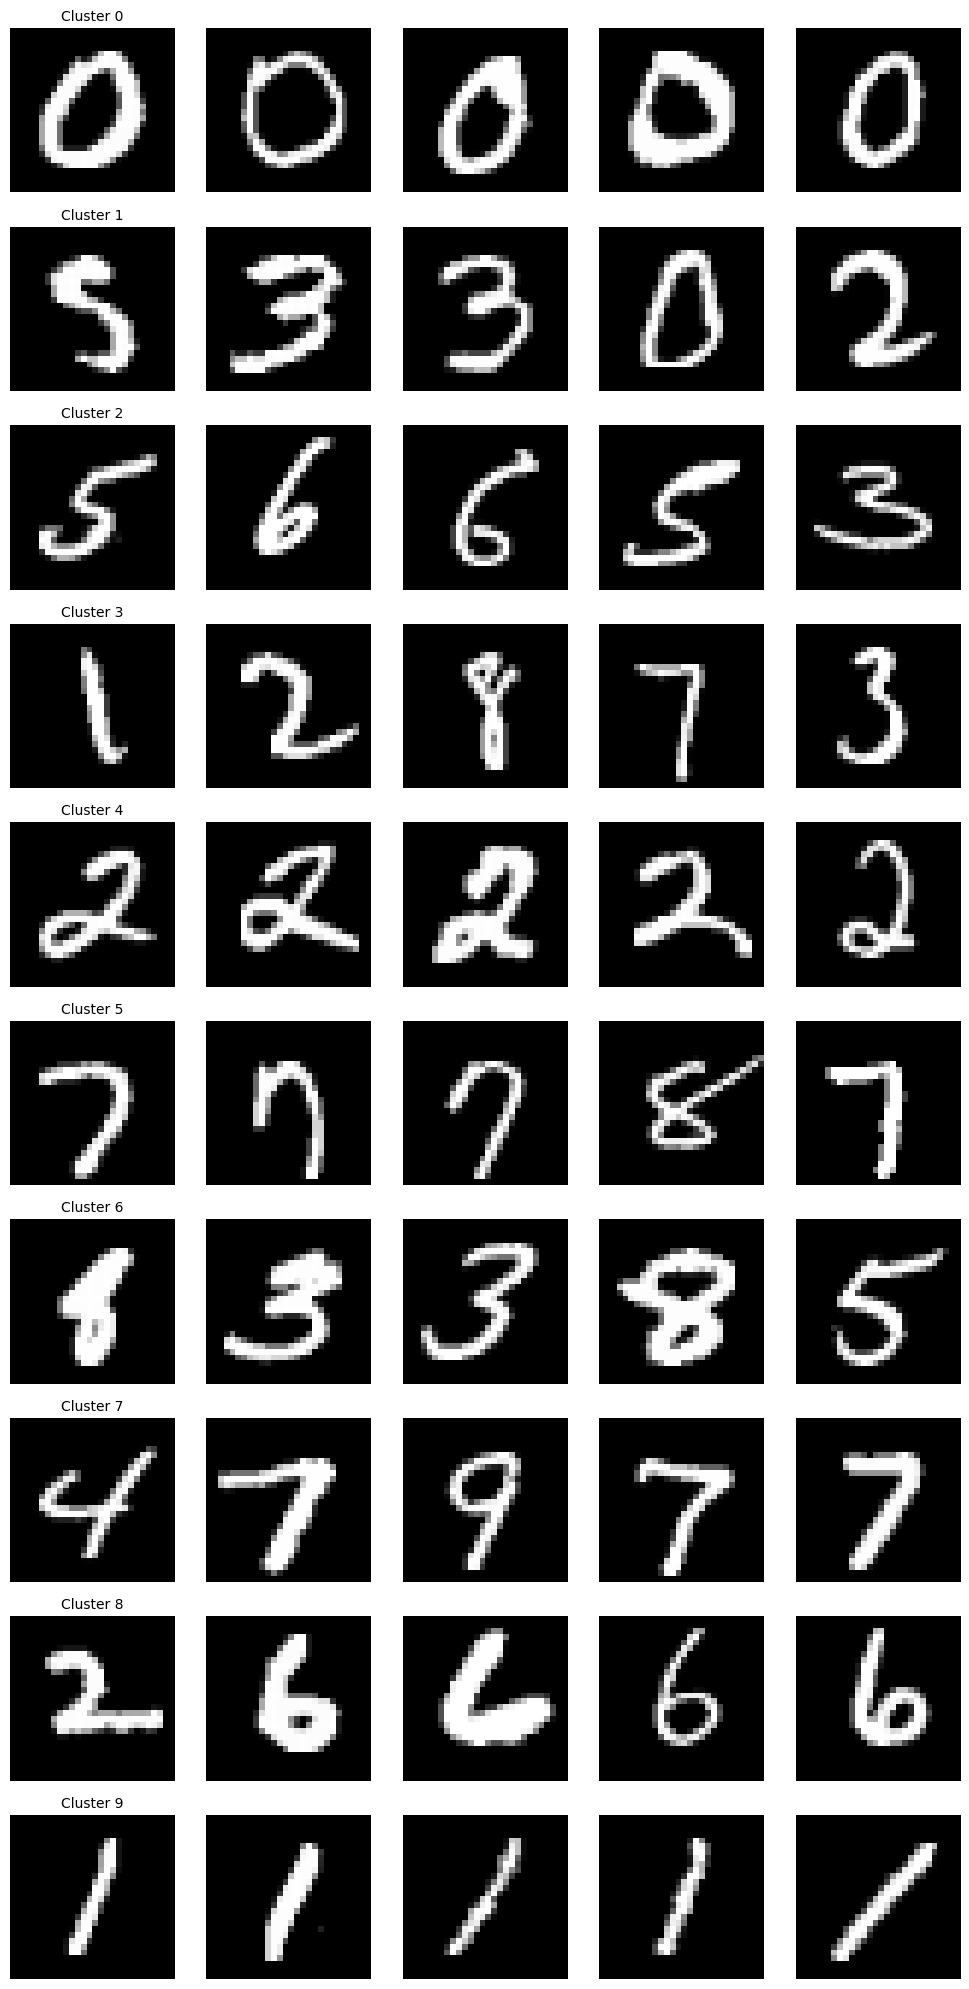

In [19]:
def visualize_clusters(X_images, labels, n_images=5):
    unique_clusters = np.unique(labels)

    plt.figure(figsize=(n_images * 2, 10 * 2))

    for cluster in unique_clusters:
        idxs = np.where(labels == cluster)[0]
        chosen = np.random.choice(idxs, size=min(n_images, len(idxs)), replace=False)

        for i, img_idx in enumerate(chosen):
            plt_idx = cluster * n_images + i + 1
            plt.subplot(10, n_images, plt_idx)
            plt.imshow(X_images[img_idx], cmap="gray")
            plt.axis("off")
            if i == 0:
                plt.title(f"Cluster {cluster}", fontsize=10)

    plt.tight_layout()
    plt.show()


visualize_clusters(X_images, kmeans_labels)


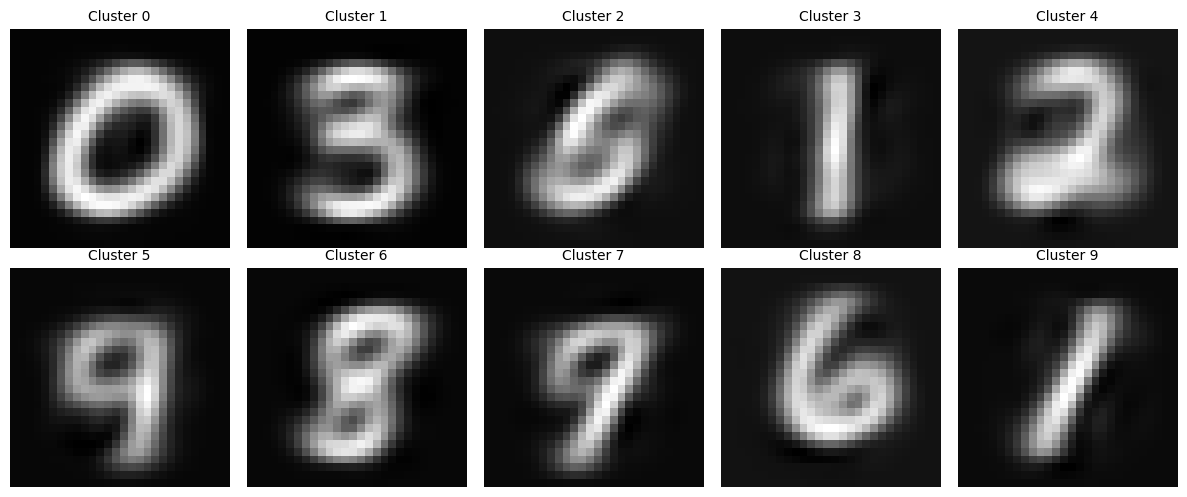

In [20]:
# Reconstruct K-Means centroids back to image space
centroids = pca.inverse_transform(kmeans.cluster_centers_)
centroid_imgs = centroids.reshape(-1, 28, 28)

def plot_kmeans_centers(centroid_imgs):
    rows, cols = 2, 5
    plt.figure(figsize=(12, 5))

    for i in range(10):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(centroid_imgs[i], cmap='gray')
        plt.title(f"Cluster {i}", fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_kmeans_centers(centroid_imgs)



### GMM with High PCA Dimensions
I initially trained GMM models using high PCA dimensions (100–200), testing multiple covariance types, initialisation schemes, and mixture sizes (8, 10, and 12 components).  
Among these, **12 components** gave the highest scores, but the overall performance was still poor: silhouette values were extremely low, ARI/NMI barely improved, and runtime increased sharply due to expensive covariance estimation.  

Since MNIST contains 10 digit classes, I followed the same reasoning as in K-Means and fixed **n_components = 10** for all subsequent comparisons.  
These results showed that high-dimensional PCA does **not** help GMM and likely introduces noise.


In [ ]:
'''
# High PCA dimensions tested originally
pca_high_dims = [100,150,200]


# GMM first tested hyperparameter grid
gmm_first_grid = {
    "n_components": [8,10,12],                    
    "covariance_type": ["full", "diag"],
    "init_params": ["kmeans", "random"],
    "max_iter": [200]
}
'''

### GMM with Low PCA Dimensions
Since high PCA dimensions performed poorly, I repeated the experiments using **lower PCA dimensions** (10–100) while fixing the mixture size to 10 components.  
These reduced-dimension models trained faster and produced clearer trends in the evaluation metrics, making them more suitable for comparison.

Starting PCA + GMM experiments...


================ PCA = 10 components ================

Testing GMM params: {'covariance_type': 'full', 'init_params': 'kmeans', 'max_iter': 200, 'n_components': 10}
 --> Silhouette=0.1272 | ARI=0.4353 | NMI=0.5963 | time=1.63s
Testing GMM params: {'covariance_type': 'full', 'init_params': 'random', 'max_iter': 200, 'n_components': 10}
 --> Silhouette=0.0357 | ARI=0.2145 | NMI=0.3245 | time=0.45s
Testing GMM params: {'covariance_type': 'diag', 'init_params': 'kmeans', 'max_iter': 200, 'n_components': 10}
 --> Silhouette=0.1285 | ARI=0.3306 | NMI=0.4957 | time=0.65s
Testing GMM params: {'covariance_type': 'diag', 'init_params': 'random', 'max_iter': 200, 'n_components': 10}
 --> Silhouette=0.0163 | ARI=0.1456 | NMI=0.2578 | time=0.20s
Testing GMM params: {'covariance_type': 'tied', 'init_params': 'kmeans', 'max_iter': 200, 'n_components': 10}
 --> Silhouette=0.1598 | ARI=0.3363 | NMI=0.4754 | time=0.61s
Testing GMM params: {'covariance_type': 'tied', '

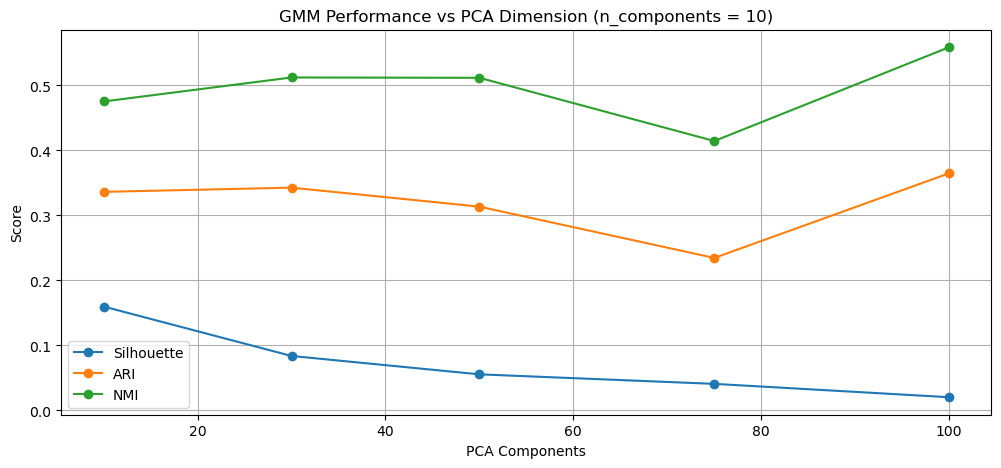

In [7]:
# GMM with Lower dimensions PCA

# PCA dimensions to test (smaller range)
pca_dims = [10, 30, 50, 75, 100]


# GMM hyperparameter grid (fixed n_components=10)
gmm_grid = {
    "n_components": [10],                    
    "covariance_type": ["full", "diag", "tied"],
    "init_params": ["kmeans", "random"],
    "max_iter": [200]
}

results = []

for dim in pca_dims:
    print(f"\n================ PCA = {dim} components ================\n")

    # PCA transform
    pca = PCA(n_components=dim, random_state=5)
    X_pca = pca.fit_transform(X)

    best_sil = -1
    best_result = None

    for params in ParameterGrid(gmm_grid):
        print(f"Testing GMM params: {params}")
        start = time.time()

        gmm = GaussianMixture(**params, random_state=42)
        gmm.fit(X_pca)
        labels = gmm.predict(X_pca)

        # Metrics
        log_likelihood = gmm.score(X_pca)     # average log-likelihood
        sil = silhouette_score(X_pca, labels, sample_size=3000)
        ari = adjusted_rand_score(y, labels)
        nmi = normalized_mutual_info_score(y, labels)
        elapsed = time.time() - start

        print(f" --> Silhouette={sil:.4f} | ARI={ari:.4f} | NMI={nmi:.4f} | time={elapsed:.2f}s")

        # track best model (by Silhouette)
        if sil > best_sil:
            best_sil = sil
            best_result = {
                "pca_dim": dim,
                "params": params,
                "silhouette": sil,
                "ari": ari,
                "nmi": nmi,
                "log_likelihood": log_likelihood,
                "time": elapsed
            }

    results.append(best_result)

    print("\n>>> Best for PCA =", dim)
    print(best_result)


# Plot metrics vs PCA dimension
dims = [r['pca_dim'] for r in results]
sil_vals = [r['silhouette'] for r in results]
ari_vals = [r['ari'] for r in results]
nmi_vals = [r['nmi'] for r in results]

plt.figure(figsize=(12, 5))
plt.plot(dims, sil_vals, marker='o', label="Silhouette")
plt.plot(dims, ari_vals, marker='o', label="ARI")
plt.plot(dims, nmi_vals, marker='o', label="NMI")
plt.xlabel("PCA Components")
plt.ylabel("Score")
plt.title("GMM Performance vs PCA Dimension (n_components = 10)")
plt.grid(True)
plt.legend()
plt.show()


### Choosing the Best PCA Dimension for GMM
From the reduced-dimension results, around **20 PCA components** gave the best balance between ARI, NMI, and silhouette score.  
Higher dimensions hurt separation, while very small dimensions removed too much structure.  
Based on this trade-off, I selected **20 components** for the final GMM clustering visualisation.

silhouette_score:  0.10768279668695542
ARI:  0.36649237659539813
nmi:  0.503872230662834
lig-likelihood:  -29.71557095872341
[0.13651696 0.06831515 0.11692436 0.09446572 0.07907869 0.09899524
 0.15543184 0.089457   0.0637305  0.09708454]
Unique cluster labels: [0 1 2 3 4 5 6 7 8 9]
Number of clusters found: 10


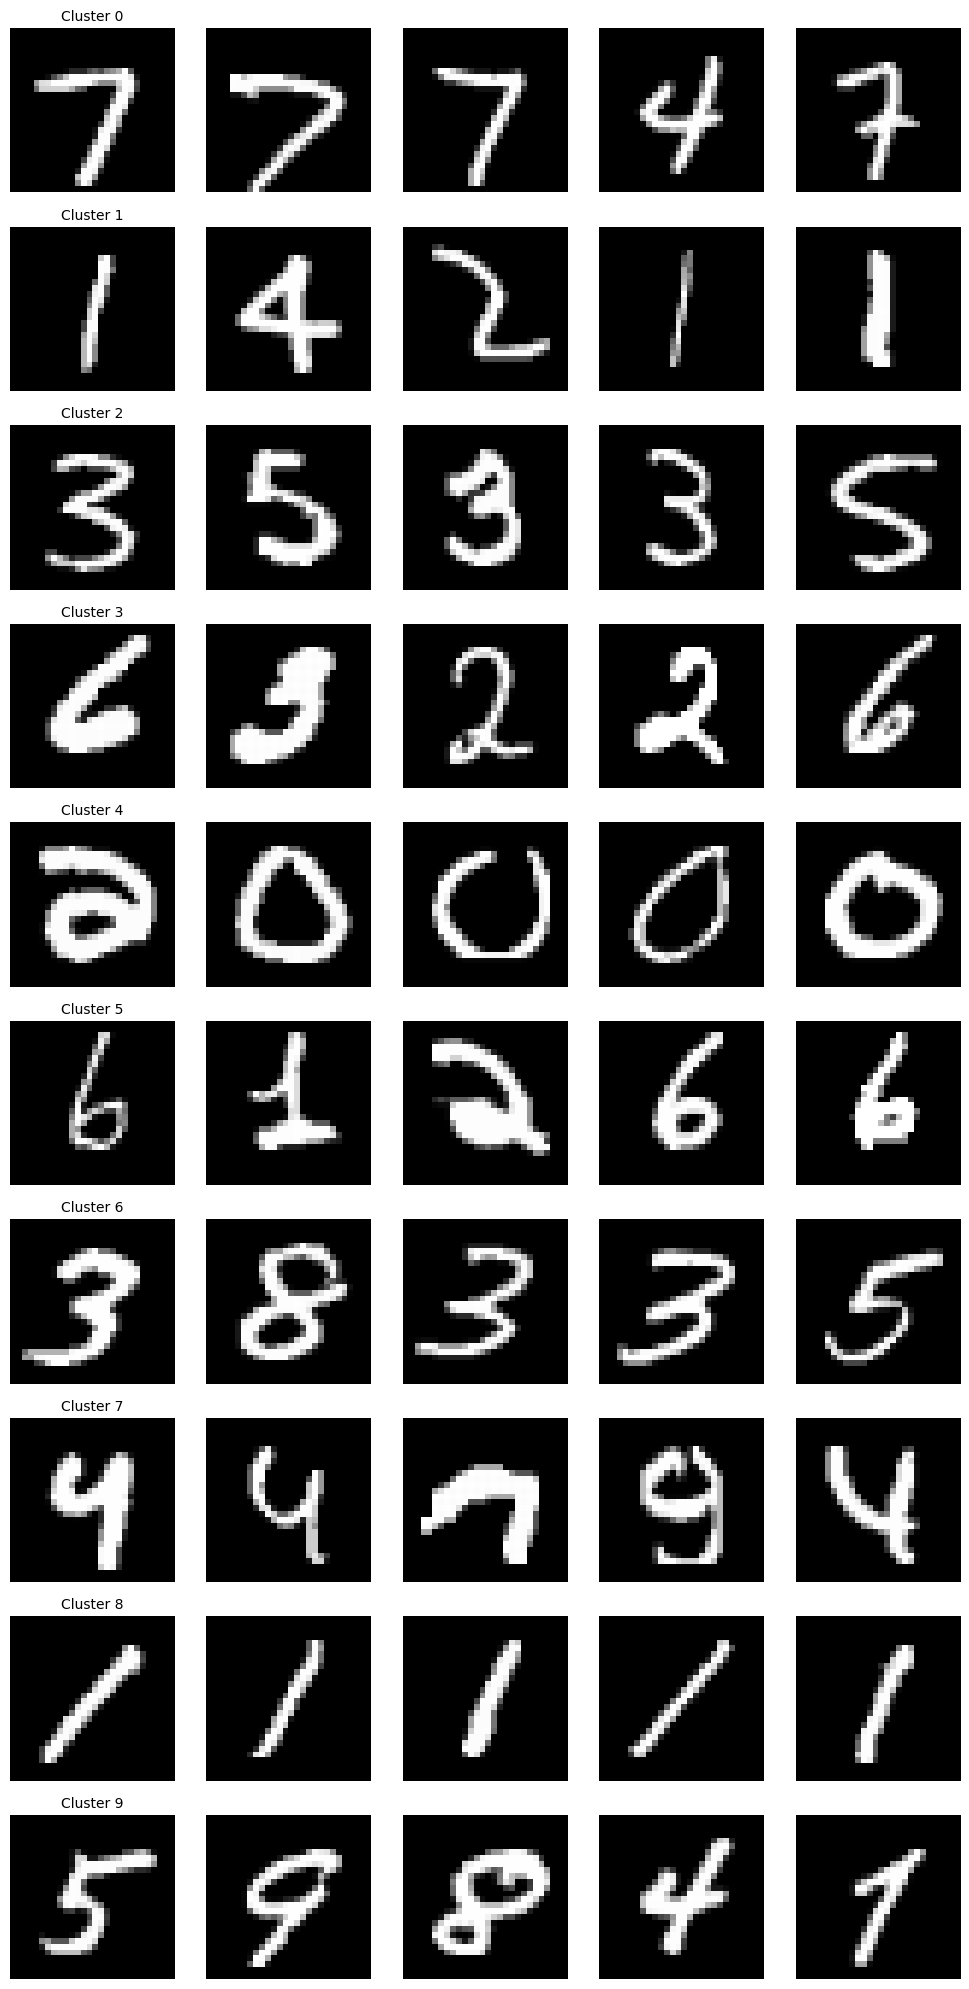

In [27]:
# PCA reduce
pca_dim = 20
pca = PCA(n_components=pca_dim, random_state=5)
X_gmm_pca = pca.fit_transform(X)


# Best GMM model
best_params = {
    'covariance_type': 'tied',   
    'init_params': 'kmeans',     
    'max_iter': 200,
    'n_components': 10          
}

gmm = GaussianMixture(**best_params, random_state=42)
gmm_labels = gmm.fit_predict(X_gmm_pca)

log_likelihood = gmm.score(X_gmm_pca)     # average log-likelihood
sil = silhouette_score(X_gmm_pca, gmm_labels, sample_size=3000)
ari = adjusted_rand_score(y, gmm_labels)
nmi = normalized_mutual_info_score(y, gmm_labels)
print("silhouette_score: ", sil)
print("ARI: ", ari)
print("nmi: ", nmi)
print("lig-likelihood: ", log_likelihood)

print(gmm.weights_)
print("Unique cluster labels:", np.unique(labels))
print("Number of clusters found:", len(np.unique(labels)))

# reshape original images for plotting
X_images = X.reshape(-1, 28, 28)


# Visualisation function
def visualize_gmm_clusters(X_images, labels, n_clusters, n_images=5):
    plt.figure(figsize=(n_images * 2, n_clusters * 2))

    for cluster in range(n_clusters):
        idxs = np.where(labels == cluster)[0]

        if len(idxs) == 0:
            continue  # skip empty cluster

        chosen = np.random.choice(idxs, size=min(n_images, len(idxs)), replace=False)

        for i, img_idx in enumerate(chosen):
            plt_idx = cluster * n_images + i + 1
            plt.subplot(n_clusters, n_images, plt_idx)
            plt.imshow(X_images[img_idx], cmap='gray')
            plt.axis("off")

            if i == 0:
                plt.title(f"Cluster {cluster}", fontsize=10)

    plt.tight_layout()
    plt.show()

visualize_gmm_clusters(X_images, gmm_labels, n_clusters=best_params['n_components'])


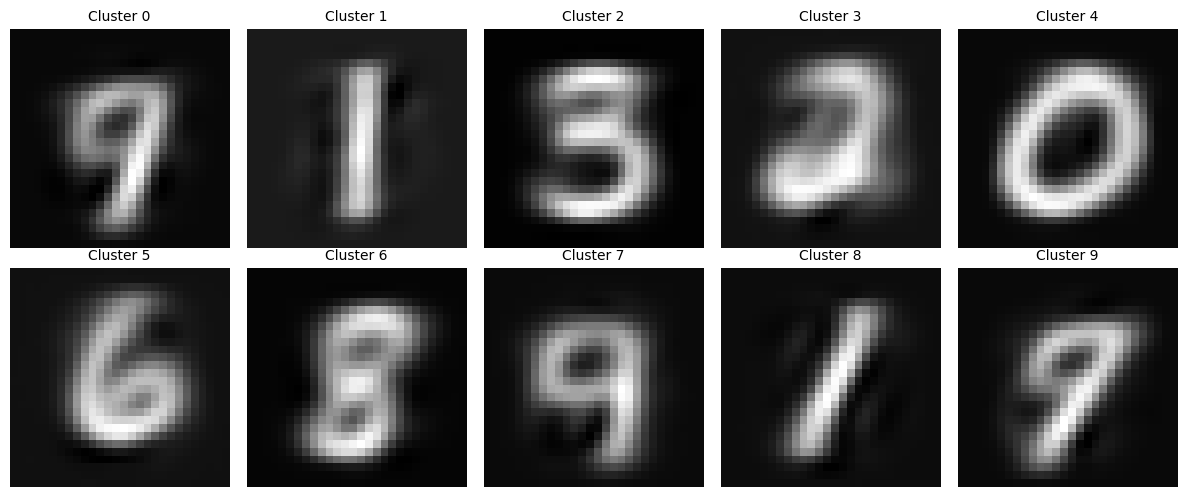

In [28]:
# Reconstruct GMM cluster means back to image space
cluster_means_pca = gmm.means_                         # shape: (n_components, pca_dim)
cluster_means_img = pca.inverse_transform(cluster_means_pca)  # back to 784 dims
cluster_means_img = cluster_means_img.reshape(-1, 28, 28)

def plot_gmm_centers(cluster_imgs):
    n = len(cluster_imgs)

    rows, cols = 2, 5
    plt.figure(figsize=(12, 5))

    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(cluster_imgs[i], cmap='gray')
        plt.title(f"Cluster {i}", fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_gmm_centers(cluster_means_img)

/var/folders/8f/9ykb6k0908s99dwvbt0n94d40000gn/T/ipykernel_97048/2125620988.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", n_clusters).colors


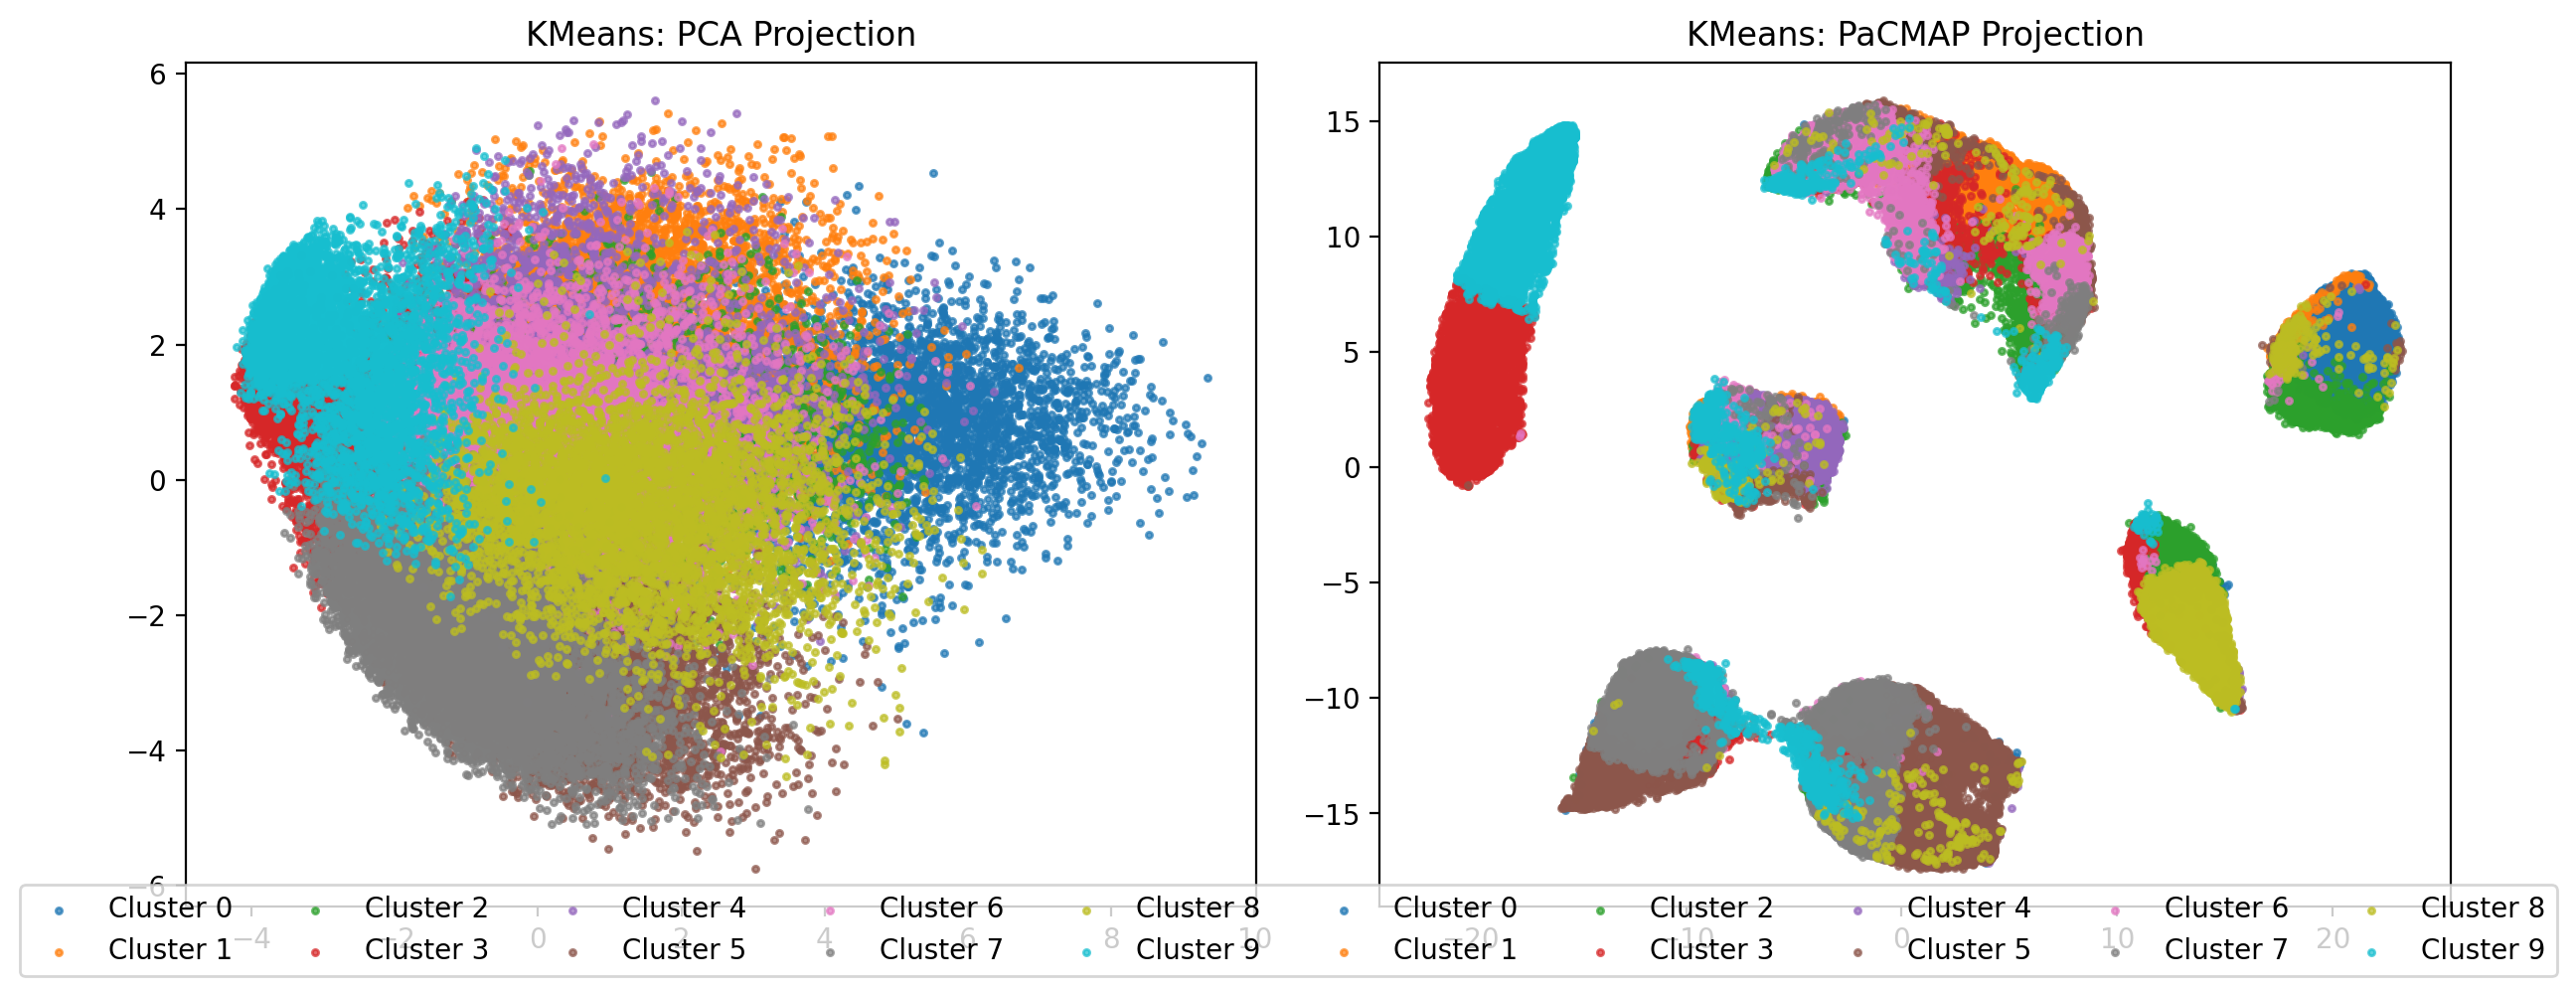

/var/folders/8f/9ykb6k0908s99dwvbt0n94d40000gn/T/ipykernel_97048/2125620988.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", n_clusters).colors


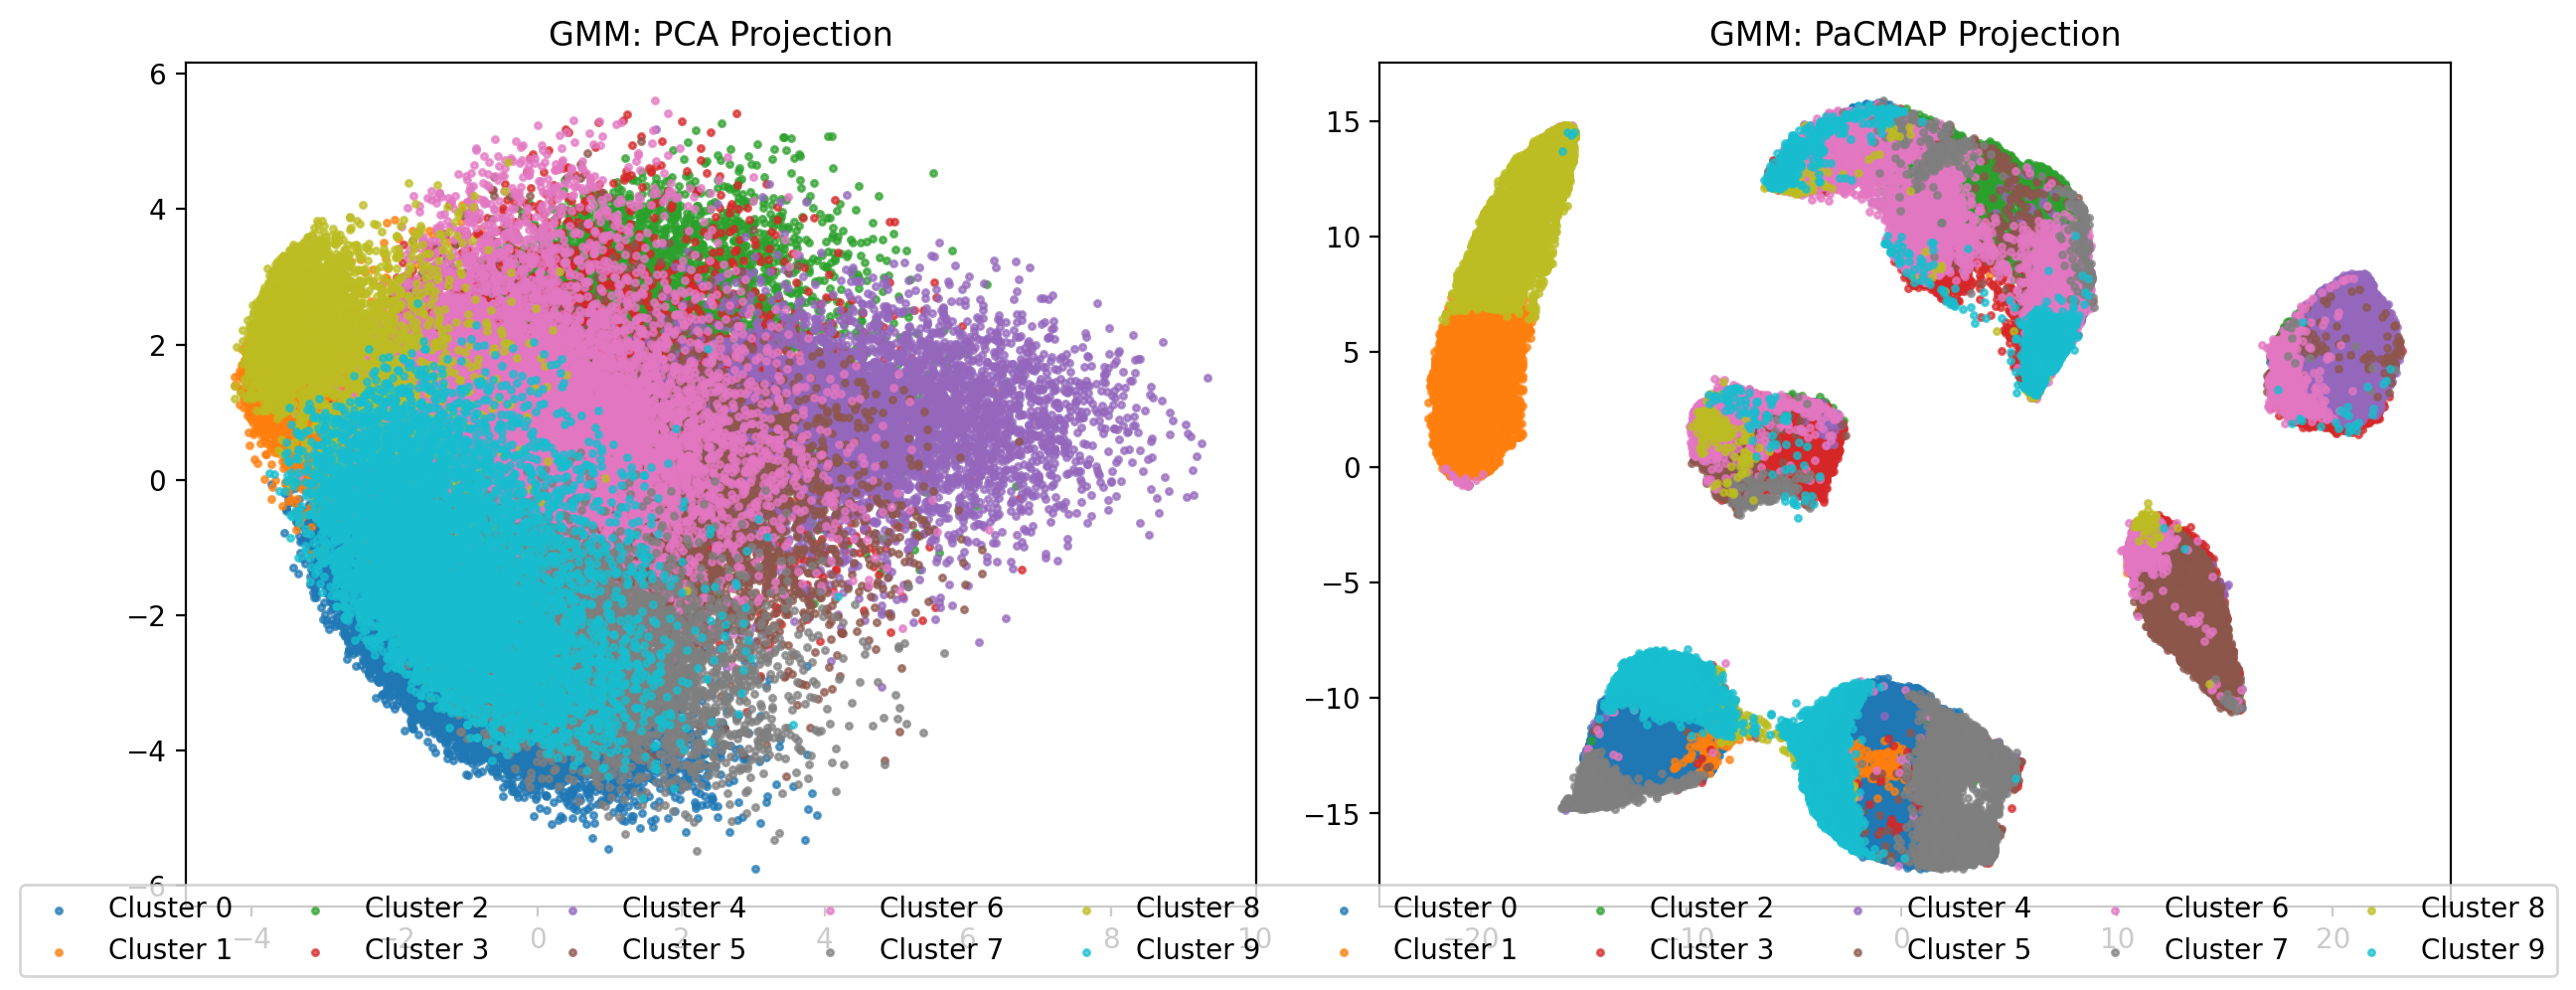

In [32]:
def visualize_clusters2(X_pca_best, cluster_labels, title_prefix):

    # 2D PCA for plotting
    pca2 = PCA(n_components=2, random_state=42)
    X_plot_pca = pca2.fit_transform(X_pca_best)

    # PaCMAP
    embedding = pacmap.PaCMAP(random_state=42)
    X_plot_pacmap = embedding.fit_transform(X_pca_best)

    n_clusters = len(np.unique(cluster_labels))
    colors = plt.cm.get_cmap("tab10", n_clusters).colors

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=200)

    # PCA scatter
    for c in range(n_clusters):
        ax1.scatter(
            X_plot_pca[cluster_labels == c, 0],
            X_plot_pca[cluster_labels == c, 1],
            s=5, color=colors[c], label=f"Cluster {c}", alpha=0.7
        )
    ax1.set_title(f"{title_prefix}: PCA Projection")

    # PACMAP scatter
    for c in range(n_clusters):
        ax2.scatter(
            X_plot_pacmap[cluster_labels == c, 0],
            X_plot_pacmap[cluster_labels == c, 1],
            s=5, color=colors[c], label=f"Cluster {c}", alpha=0.7
        )
    ax2.set_title(f"{title_prefix}: PaCMAP Projection")

    fig.legend(loc="lower center", ncol=n_clusters)
    plt.tight_layout()
    plt.show()

# Commented out as technically not part of the CW
'''
visualize_clusters2(X_kmeans_pca, kmeans_labels, title_prefix="KMeans")
visualize_clusters2(X_gmm_pca, gmm_labels, title_prefix="GMM")
'''

> **Note:** The PaCMAP visualisation method was adapted from an example in  
> *"How Many Clusters?" (Towards Data Science)*:  
> https://towardsdatascience.com/how-many-clusters-6b3f220f0ef5/  
> I modified the code for MNIST and extended it to compare K-Means and GMM clustering results.